In [3]:
import sys
# Include the working directory to PATH
sys.path.append('/xxx/PhaseField/')
from model.Initial import init_dnadiff,initial_dyna
from model.Solver import Solver
from model.Utils.Plot import drawExpDNA,plotDP,dna_exp_compare,dna_tdp_compare,plot_simulation
from scipy.ndimage import minimum_filter, maximum_filter
from model.String import String_Solver
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
para = {"m":128,"n":128,"dt":0.2,"max_iter":4000,
        "b1":0.14,"b2":0.4,"b3":-0.425,"b4":0.85,
         "Dd_0":0.3,"dd_0":7e-3,"ad_0":1e-3,
        "c1":0.6,"c2":0.6,"L1":1,"L2":1,"Critical":0.85,
        "alpha":0.008,"gamma":0,"beta":0,"base":0.3,"dna_level":0.5}
eta,phi,chi,d_init,p_init = init_dnadiff(para,radius=13,dna_level_0=2)

20.78306845757653


/home/bili/Apps/Mamba/envs/PhaseField/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /workspace/croot/pytorch_1692381528408/work/aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/home/bili/Apps/Mamba/envs/PhaseField/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bili/Apps/Mamba/envs/PhaseField/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bili/Apps/Mamba/envs/PhaseField/lib/python3.11/site-pa

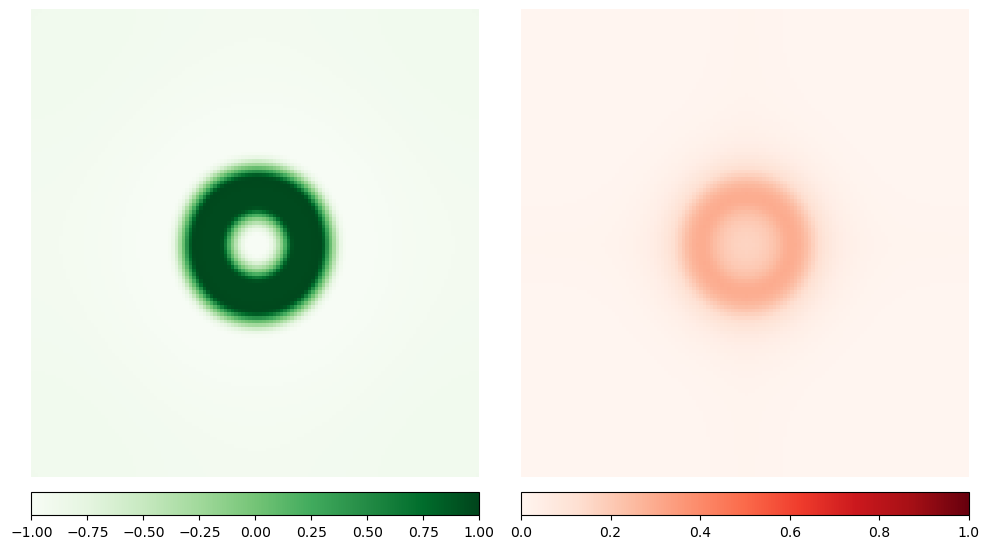

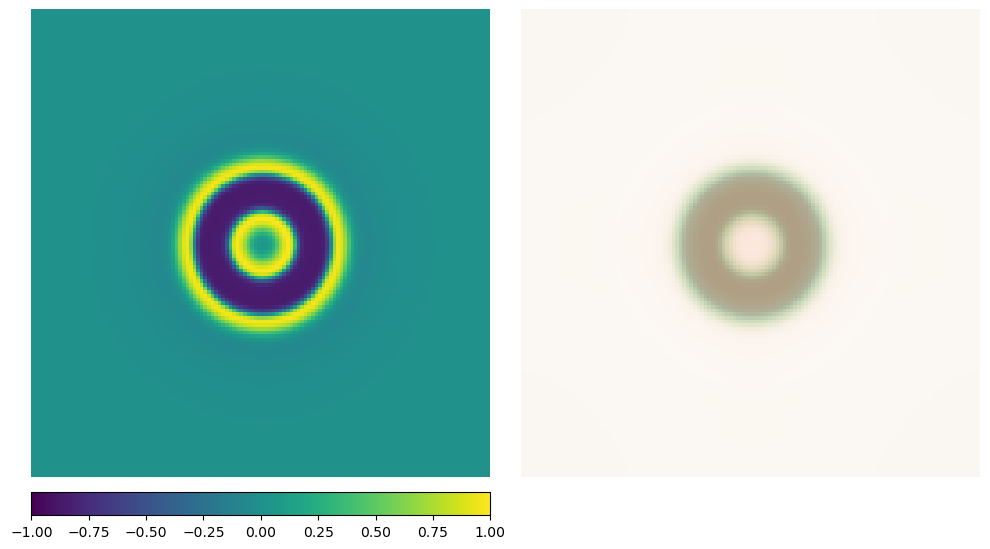

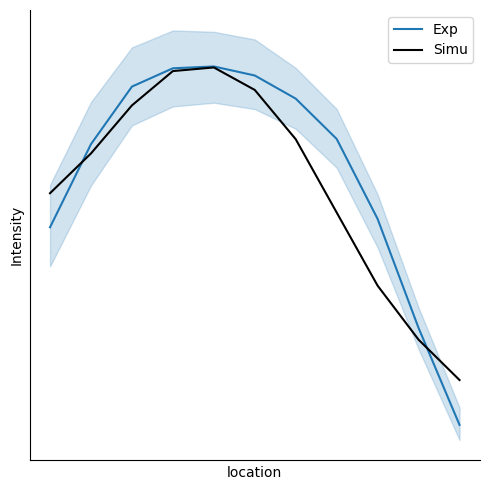

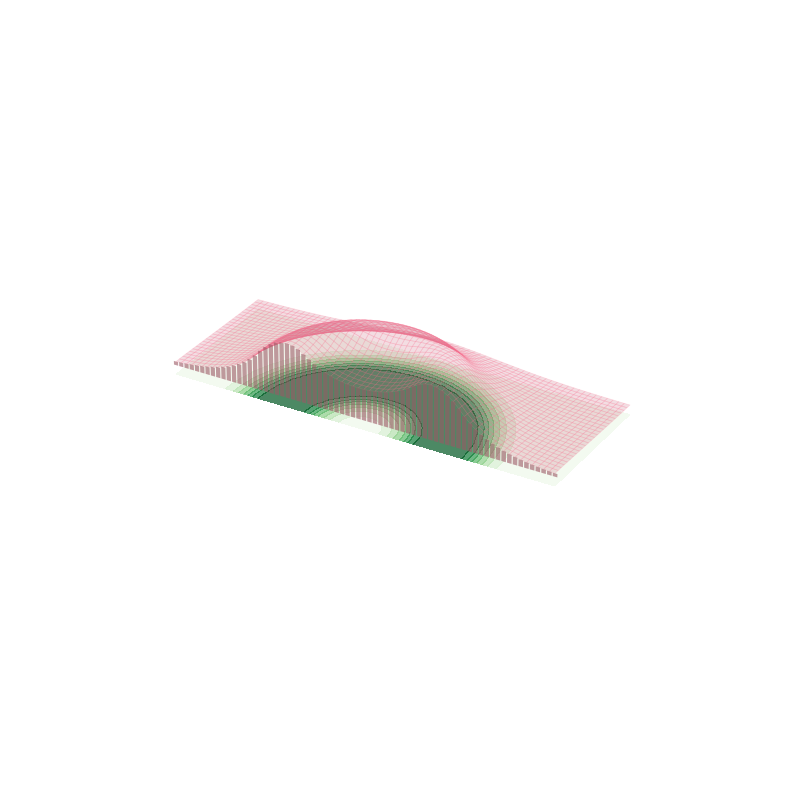

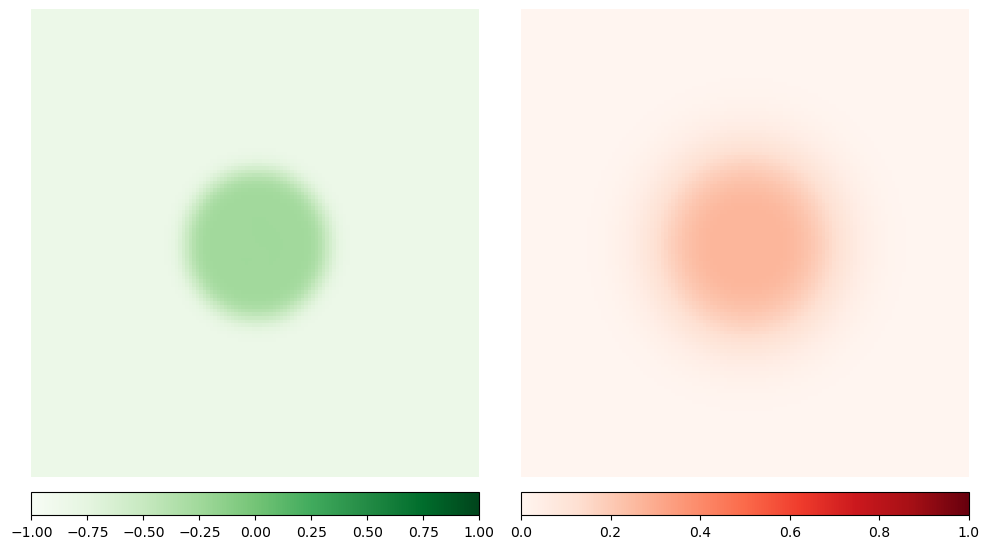

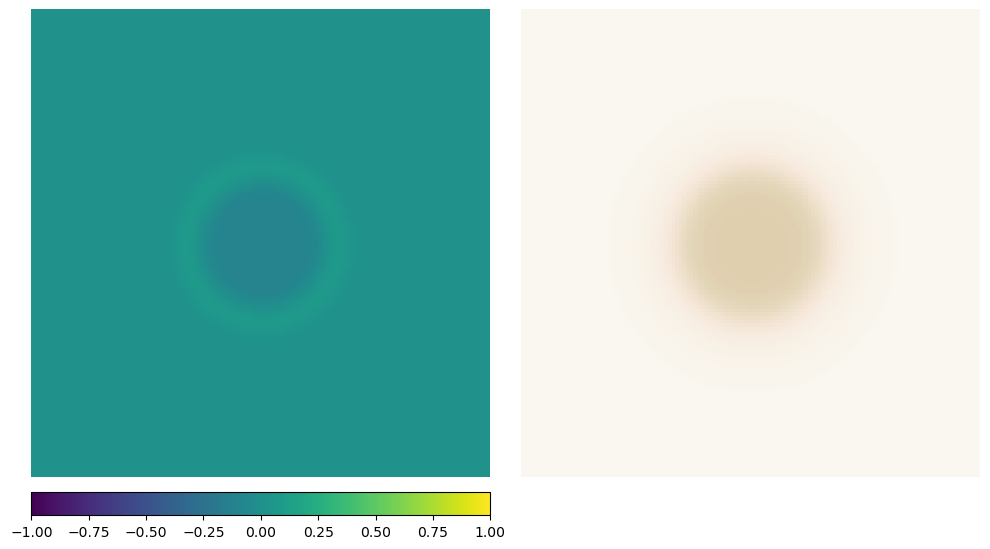

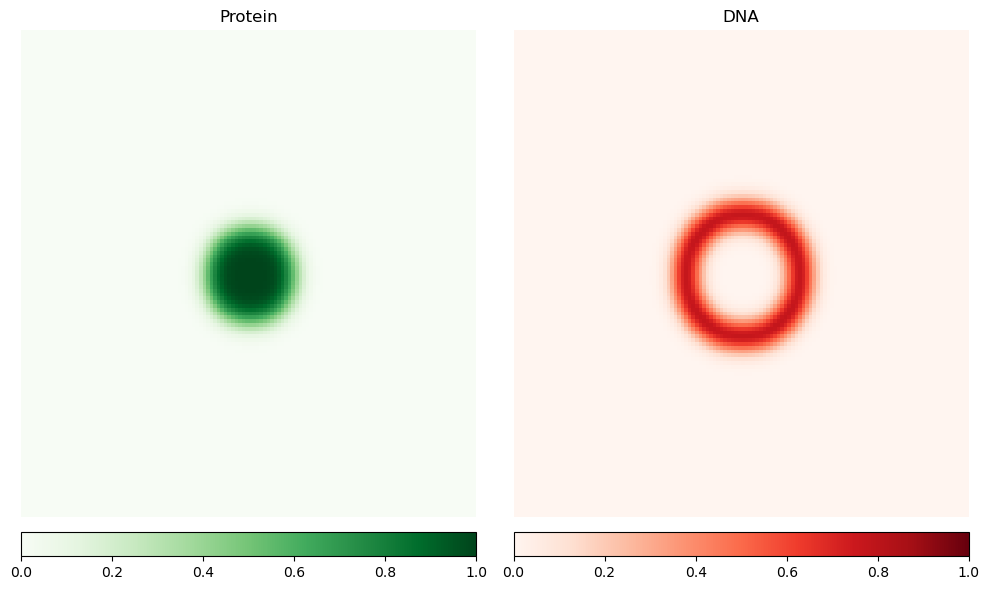

In [2]:
def make_plot(para):
    init_order = {"eta":torch.Tensor(eta),"phi":torch.Tensor(phi),"chi":{"0":torch.Tensor(chi["0"])}}
    solver = Solver(para,init_order,logger=None,target_region="-phi",DNA=True,crit=0.15)
    solver.initialize()
    solver.solve(ifwrite=False,record_sequence=[0,4000])
    result = solver.getResult()
    start,final = map(result.get,[0,4000]) 
    fig_final1,fig_final2 = plot_simulation(final,dna_alpha=0.7)
    fig_final1.savefig("./FinalFigure/sim_exp1.pdf",dpi=300,bbox_inches='tight')
    fig_final2.savefig("./FinalFigure/sim_exp2.pdf",dpi=300,bbox_inches='tight')
    fig_dna,ax_dna = plt.subplots(figsize=(5,5))
    ax_dna = dna_exp_compare(ax_dna,final[2]["0"].real,start=71,end=89,multiplier=290)
    fig_dna.tight_layout()
    fig_dna.savefig("./FinalFigure/sim_dna.pdf",dpi=300,bbox_inches='tight')
    fig_dna_3d = drawExpDNA(final[2]["0"].real,final[0].real)
    fig_dna_3d.savefig("./FinalFigure/sim_dna3d.pdf",dpi=300,bbox_inches='tight')
    fig_start1,fig_start_2 = plot_simulation(start,dna_alpha=0.7)
    fig_start1.savefig("./FinalFigure/sim_expstart1.pdf",dpi=300,bbox_inches='tight')
    fig_start_2.savefig("./FinalFigure/sim_expstart2.pdf",dpi=300,bbox_inches='tight')
    fig_dp = plotDP(d_init,p_init)
    fig_dp.savefig("./FinalFigure/sim_dp.pdf",dpi=300,bbox_inches='tight')
    return
    
    
make_plot(para)

16.717644889044575


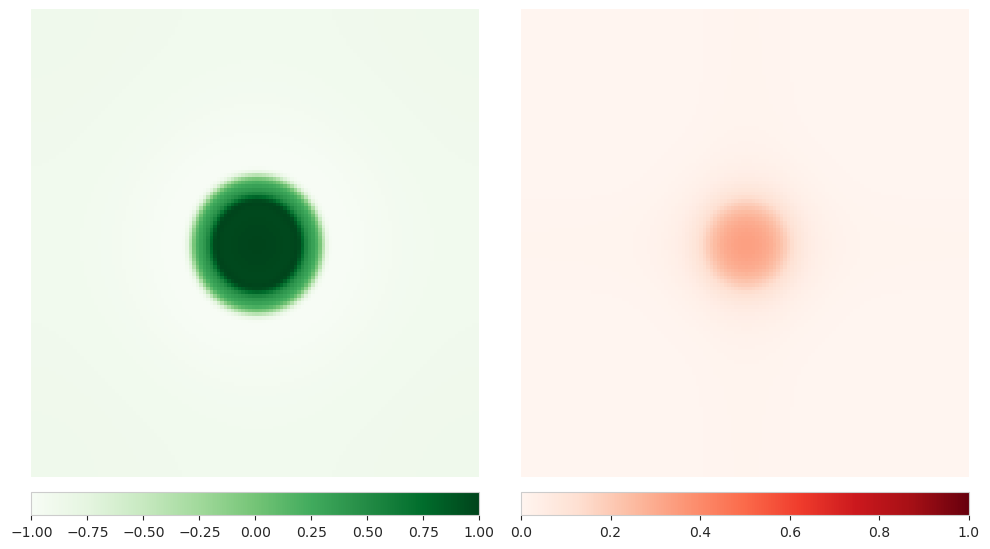

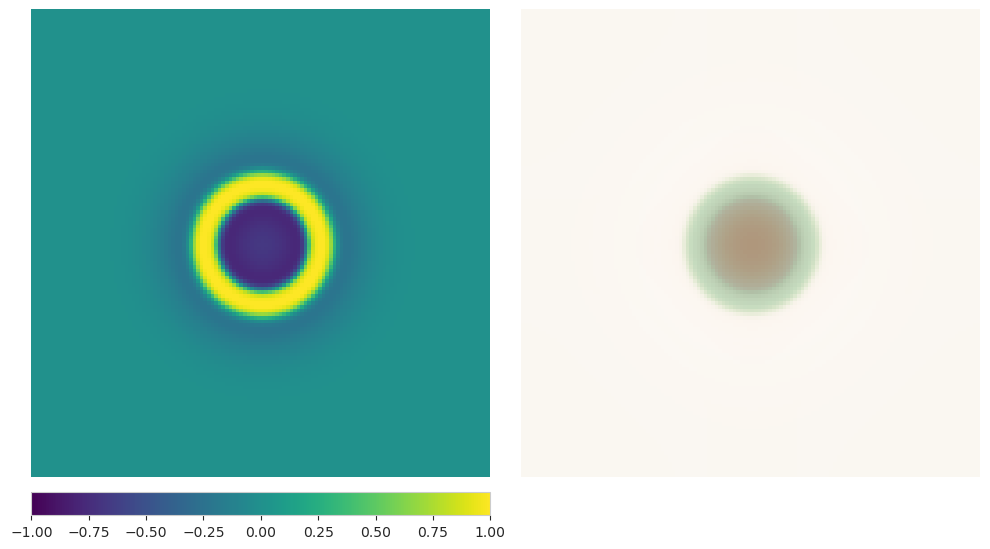

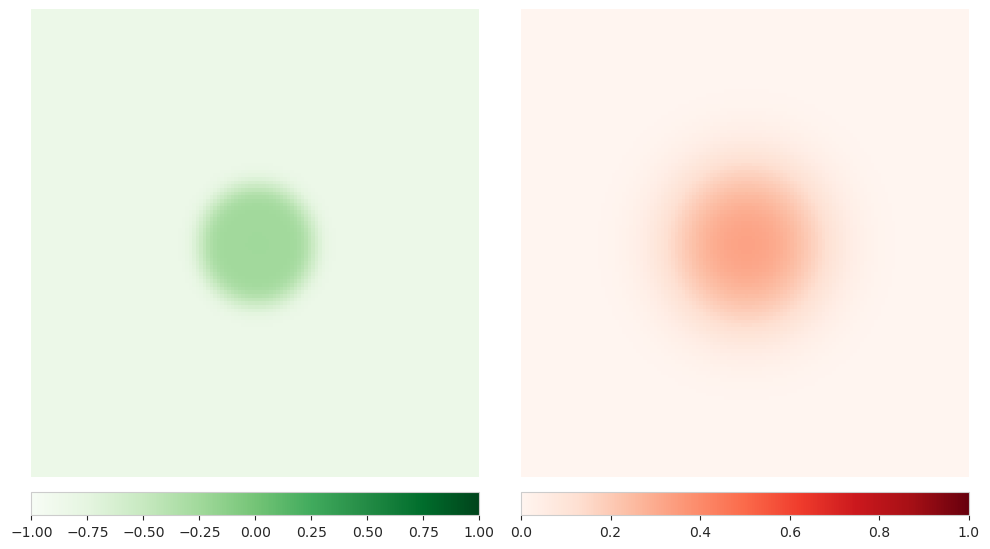

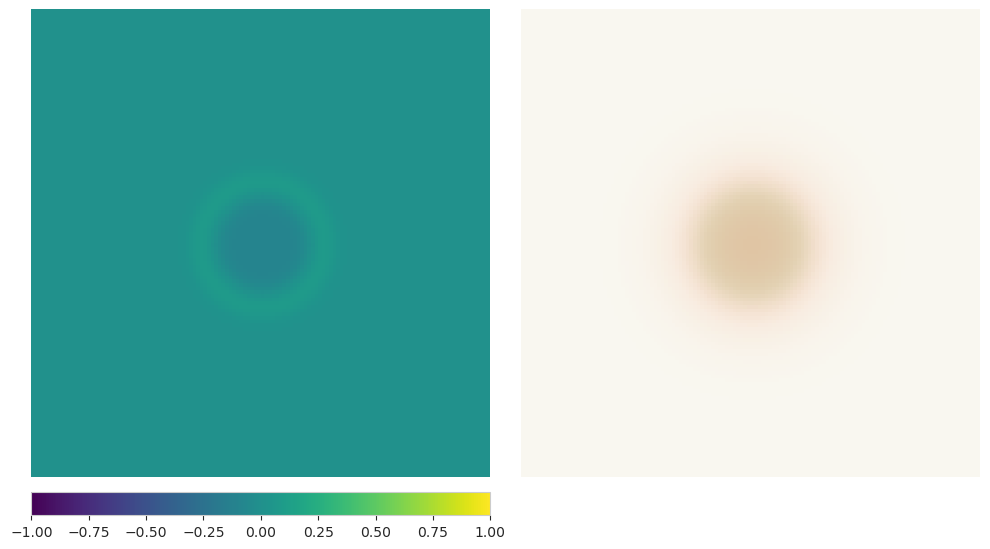

In [3]:
def plotlowerb1():
    para_lb1 = para.copy()
    para_lb1['b1'] = 0.04
    eta,phi,chi,d_init,p_init = init_dnadiff(para_lb1,radius=10,dna_level_0=2)
    init_order = {"eta":torch.Tensor(eta),"phi":torch.Tensor(phi),"chi":{"0":torch.Tensor(chi["0"])}}
    solver = Solver(para_lb1,init_order,logger=None,target_region="-phi",DNA=True,crit=0.5)
    solver.initialize()
    solver.solve(ifwrite=False,record_sequence=[0,4000])
    result = solver.getResult()
    start,final = map(result.get,[0,4000]) 
    fig_final1,fig_final2 = plot_simulation(final,dna_alpha=0.7)
    fig_final1.savefig("./FinalFigure/sim_lowb11.pdf",dpi=300,bbox_inches='tight')
    fig_final2.savefig("./FinalFigure/sim_lowb12.pdf",dpi=300,bbox_inches='tight')
    fig_start1,fig_start2 = plot_simulation(start,dna_alpha=0.7)
    fig_start1.savefig("./FinalFigure/sim_lowb11start.pdf",dpi=300,bbox_inches='tight')
    fig_start2.savefig("./FinalFigure/sim_lowb12start.pdf",dpi=300,bbox_inches='tight')
    return 
plotlowerb1()

16.717644889044575


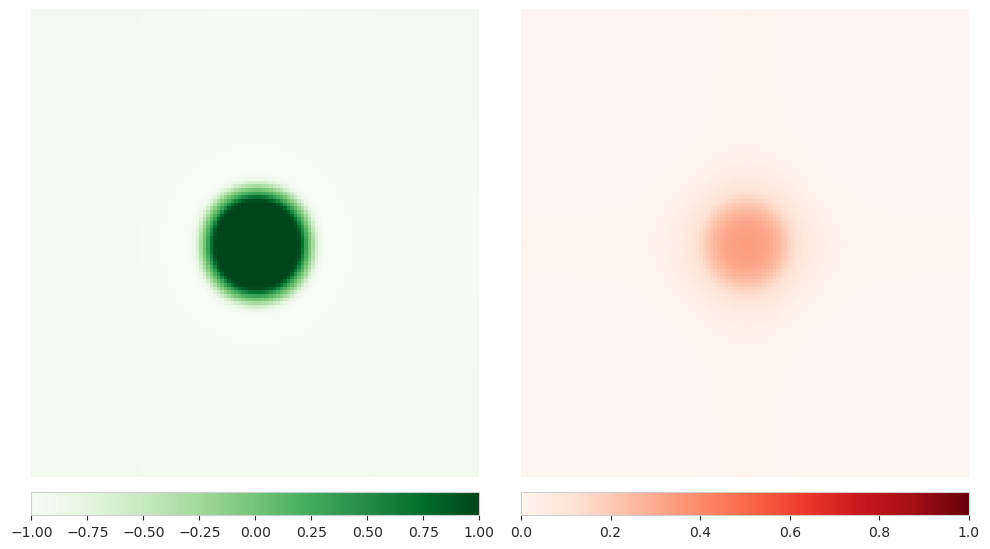

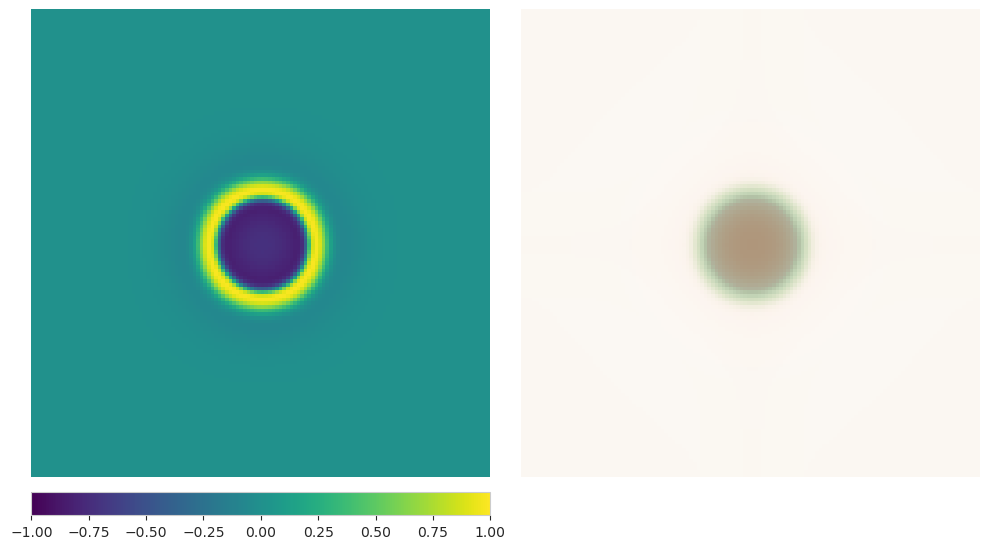

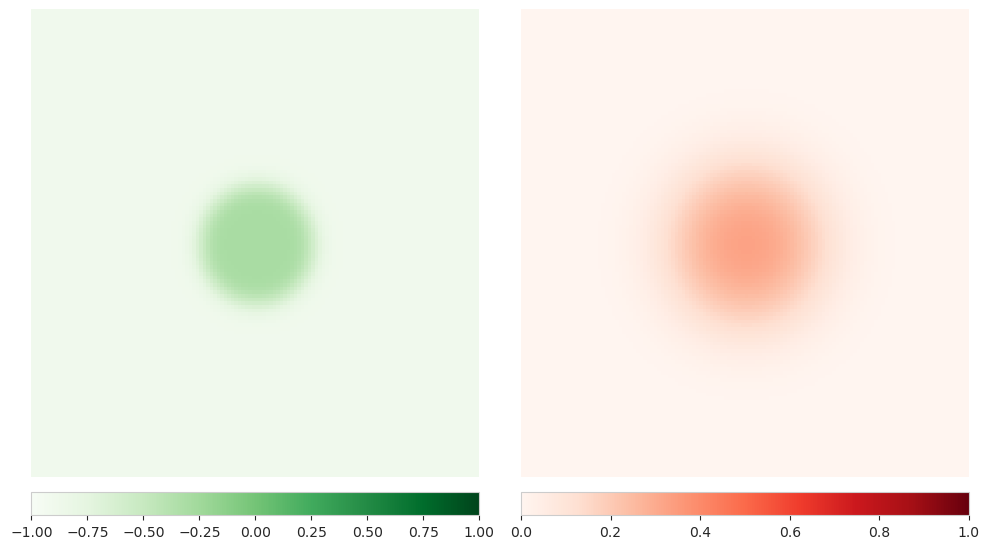

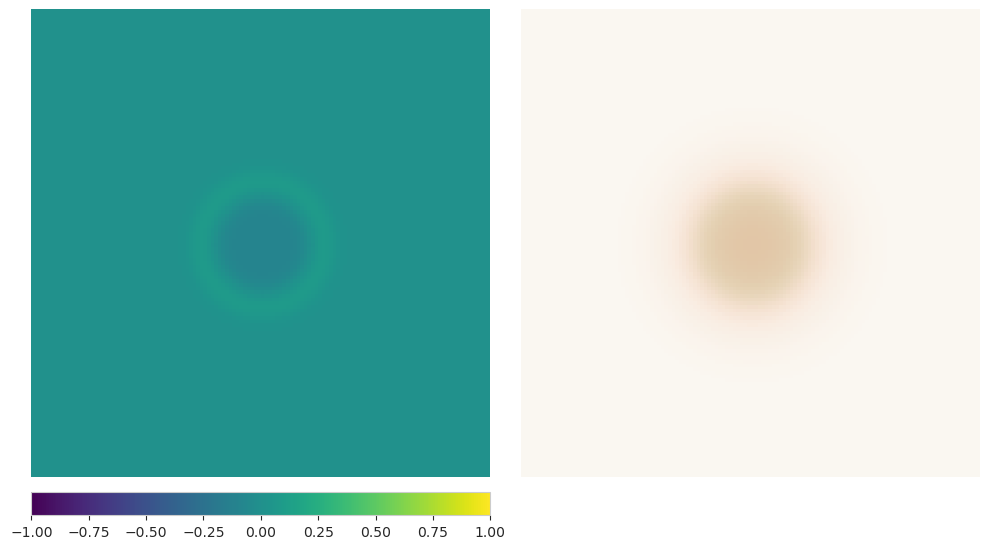

In [4]:
def plothighpsi():
    para_hpsi = para.copy()
    para_hpsi['Critical'] = 0.9
    eta,phi,chi,d_init,p_init = init_dnadiff(para_hpsi,radius=10,dna_level_0=2)
    init_hpsi = {"eta":torch.Tensor(eta),"phi":torch.Tensor(phi),"chi":{"0":torch.Tensor(chi["0"])}}
    solver = Solver(para_hpsi,init_hpsi,logger=None,target_region="-phi",DNA=True,crit=0.5)
    solver.initialize()
    solver.solve(ifwrite=False,record_sequence=[0,4000])
    result = solver.getResult()
    start,final = map(result.get,[0,4000]) 
    fig_final1,fig_final2 = plot_simulation(final,dna_alpha=0.7)
    fig_final1.savefig("./FinalFigure/sim_highpsi1.pdf",dpi=300,bbox_inches='tight')
    fig_final2.savefig("./FinalFigure/sim_highpsi2.pdf",dpi=300,bbox_inches='tight')
    fig_start1,fig_start2 = plot_simulation(start,dna_alpha=0.7)
    fig_start1.savefig("./FinalFigure/sim_highpsi1start.pdf",dpi=300,bbox_inches='tight')
    fig_start2.savefig("./FinalFigure/sim_highpsi2start.pdf",dpi=300,bbox_inches='tight')
    return 
plothighpsi()

-0.00026759138247208587 -0.8044067163528265 0.04559328364717334


/home/bili/Apps/Mamba/envs/PhaseField/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bili/Apps/Mamba/envs/PhaseField/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bili/Apps/Mamba/envs/PhaseField/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/bili/Apps/Mamba/envs/PhaseField/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be remov

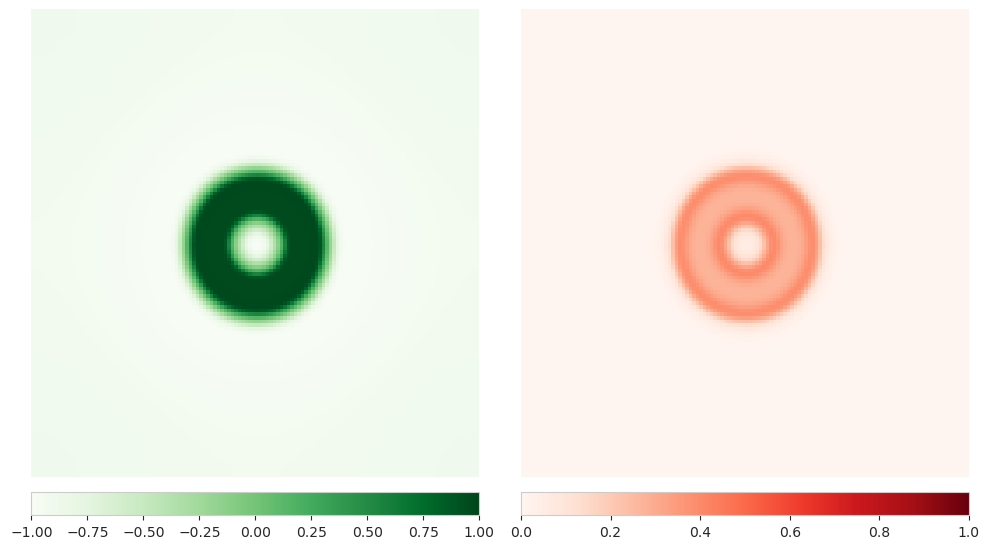

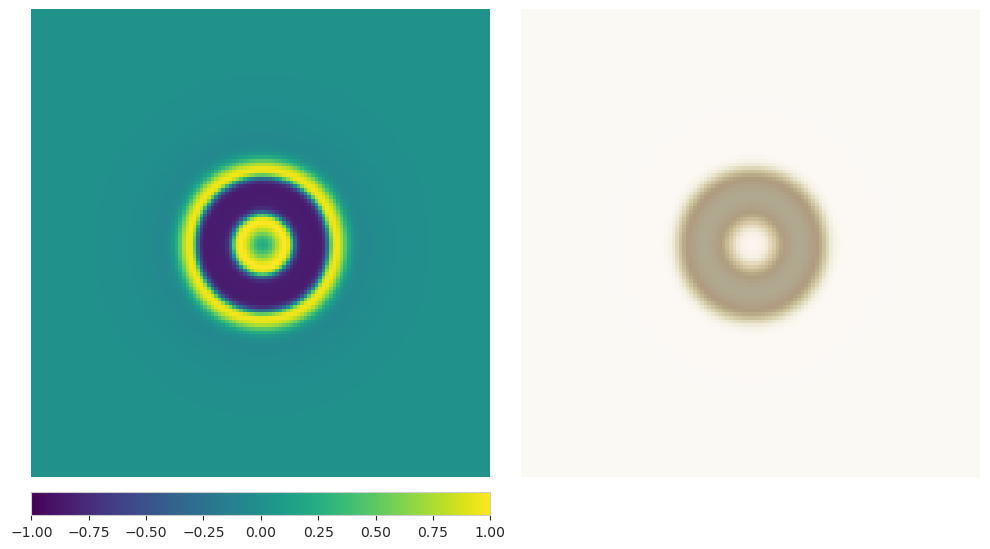

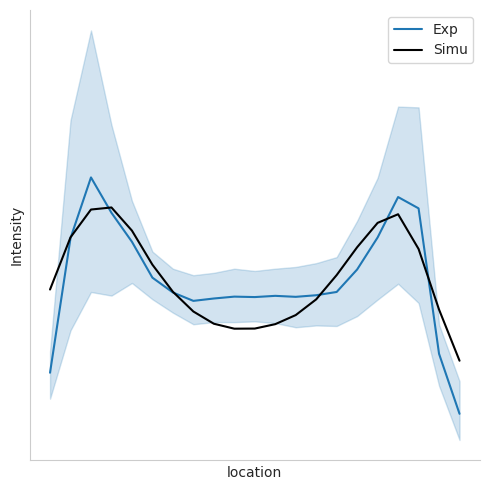

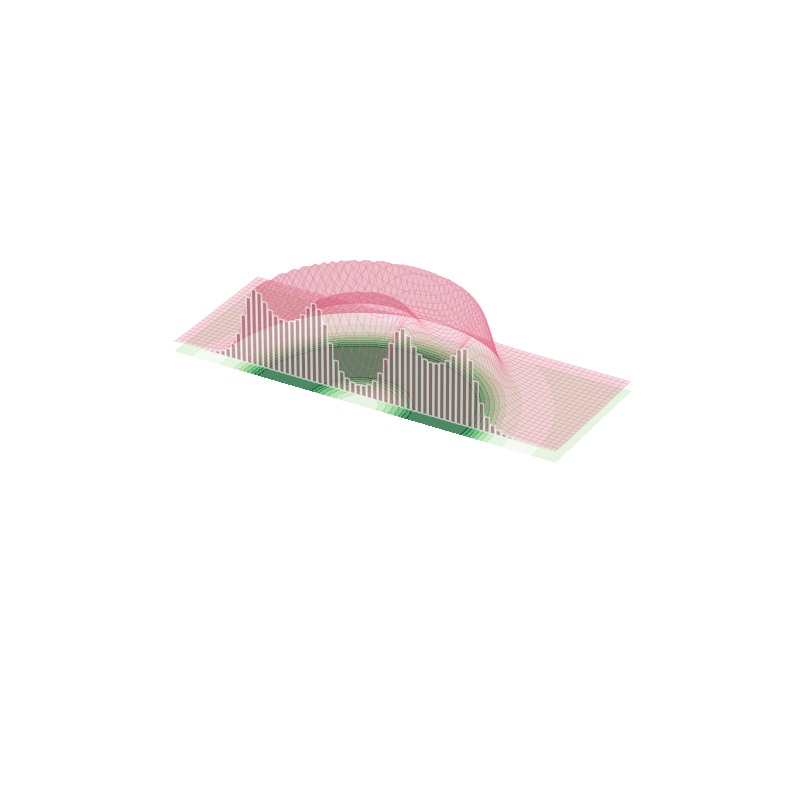

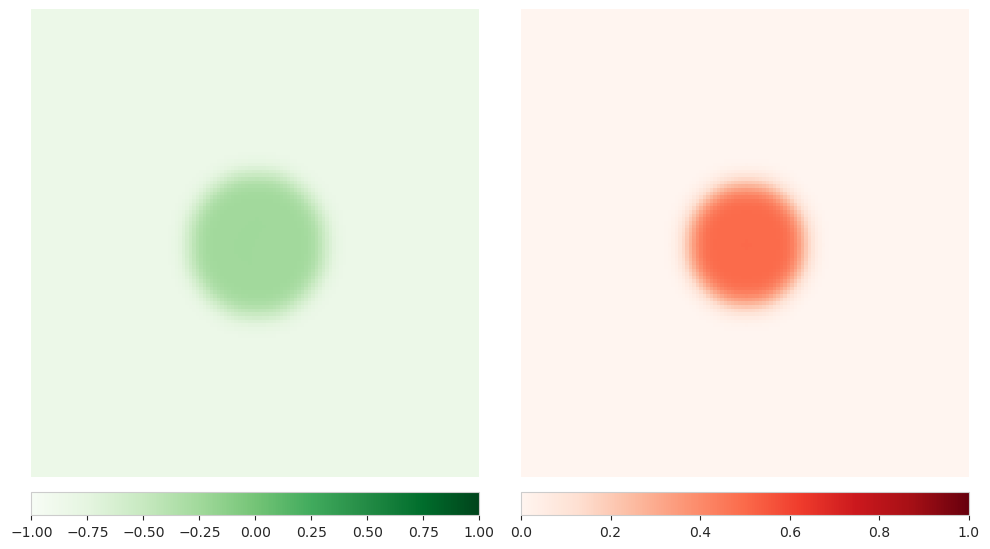

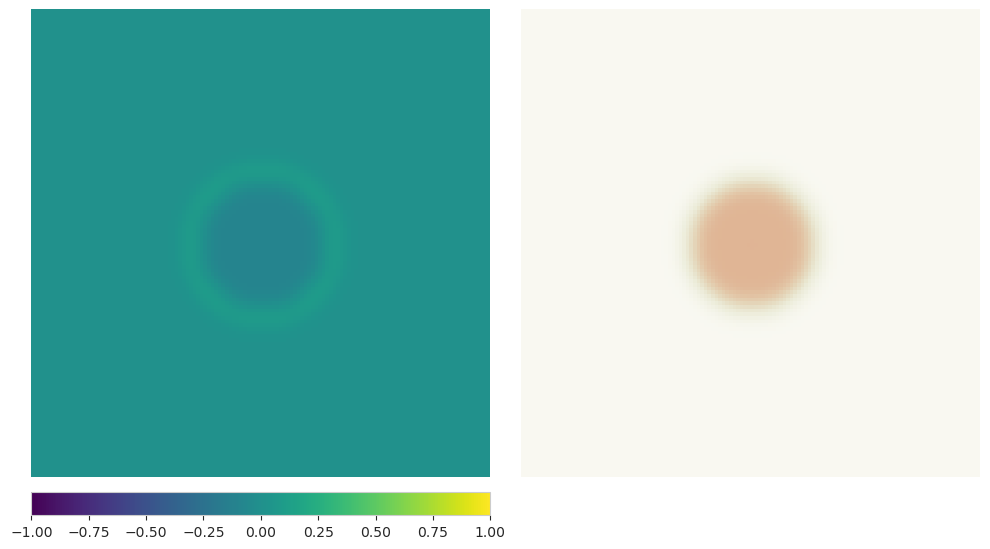

In [5]:
def psiDNA():
    para_tdp = para.copy()
    para_tdp.update({"Dd_0":0.2,"dd_0":7e-2,"ad_0":6e-3,"DNA_level":1})
    eta,phi,chi = initial_dyna(para_tdp)
    init_order = {"eta":eta,"phi":phi,"chi":{"0":chi}}
    solver = Solver(para_tdp,init_order,logger=None,target_region="eta+phi",DNA=True)
    solver.initialize()
    solver.solve(ifwrite=False,record_sequence=[0,4000])
    result = solver.getResult()
    start,final = map(result.get,[0,4000]) 
    fig_final1,fig_final2 = plot_simulation(final,dna_alpha=0.6)
    fig_final1.savefig("./FinalFigure/sim_tdp1.pdf",dpi=300,bbox_inches='tight')
    fig_final2.savefig("./FinalFigure/sim_tdp2.pdf",dpi=300,bbox_inches='tight')
    fig_dna,ax_dna = plt.subplots(figsize=(5,5))
    ax_dna = dna_tdp_compare(ax_dna,final[2]["0"].real,start=70,end=86)
    fig_dna.tight_layout()
    fig_dna.savefig("./FinalFigure/sim_tdp.pdf",dpi=300,bbox_inches='tight')
    fig_dna_3d = drawExpDNA(final[2]["0"].real,final[0].real)
    fig_dna_3d.savefig("./FinalFigure/sim_tdp3d.pdf",dpi=300,bbox_inches='tight')
    fig_start1,fig_start_2 = plot_simulation(start,dna_alpha=0.6)
    fig_start1.savefig("./FinalFigure/sim_tdpstart1.pdf",dpi=300,bbox_inches='tight')
    fig_start_2.savefig("./FinalFigure/sim_tdpstart2.pdf",dpi=300,bbox_inches='tight')
psiDNA()

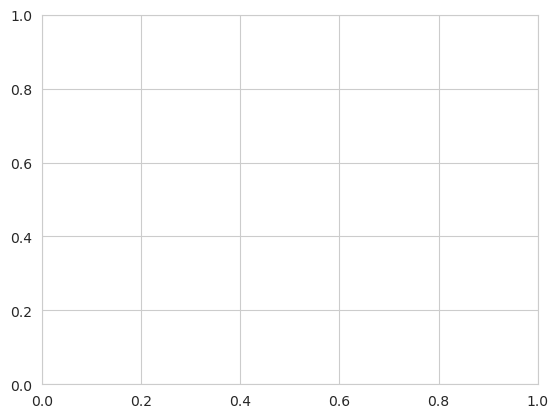

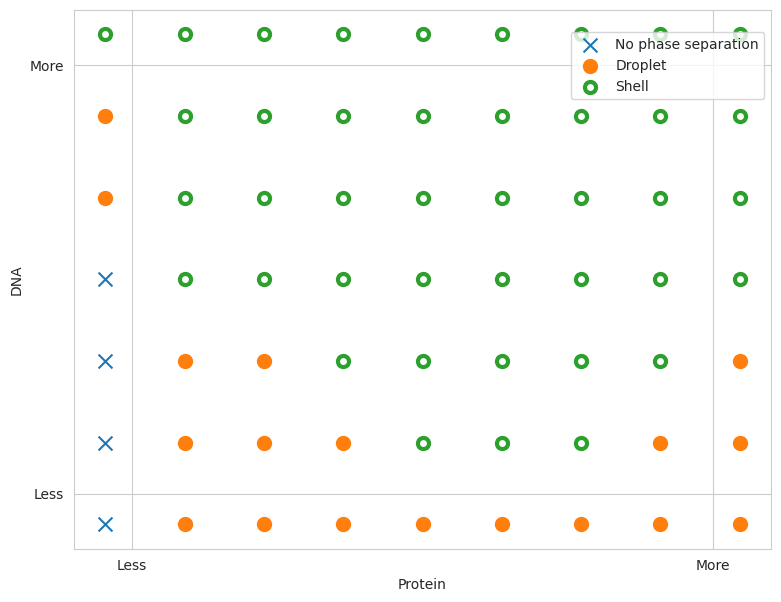

In [7]:
plt.cla()
data_raw = pd.read_csv("./PhaseDiagramNew/result_dna_anno.csv").sort_values(by=['dna'],ascending=False)
#data_raw['dna'] = -data_raw['dna']
#data['ring_base'] = -data['ring_base']
data_raw = data_raw[data_raw['dna']!=0.44]
fig_2d,ax_2d = plt.subplots(figsize=(9,7))
markers = {"Y":'$\circ$',"N":'o',"E":'x'}
name = {"Y":"Shell","N":"Droplet","E":"No phase separation"}
for marker, d in data_raw.groupby('shell'):
    ax_2d.scatter(x=d['protein'], y=d['dna'],marker=markers[marker],s=100,label=name[marker])

ax_2d.set_xticks([0.2,0.64],['Less','More'])
ax_2d.set_yticks([0.55,0.97],['Less','More'])
ax_2d.set_xlabel("Protein")
ax_2d.set_ylabel("DNA")
fig_2d.legend(loc='right',bbox_to_anchor=(0.9,0.8))
fig_2d.savefig("./FinalFigure/phase_diagram2d.pdf",dpi=300)